<a href="https://colab.research.google.com/github/mrojoh/ctg-actividad-ml/blob/main/Actividad_ML_CTG_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Detección de Anomalías y Técnicas de Agrupamiento
**Curso: Aprendizaje Automático — Maestría en IA, EP Newman**
**Dataset:** Cardiotocography (CTG) — fuente oficial del profesor (Dr. Oscar Jiménez Flores)

Este notebook sigue la misma estructura y orden que la plantilla oficial compartida en clase, con dos correcciones metodológicas señaladas explícitamente donde corresponde (identificación correcta de variables categóricas, y tratamiento diferenciado de las 3 filas que no son pacientes reales).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# Fuente: repositorio propio en GitHub (dataset original de Kaggle, sin depurar)
url = 'https://raw.githubusercontent.com/mrojoh/ctg-actividad-ml/main/CTG.csv'
df = pd.read_csv(url)
df.shape

(2129, 40)

# 1. EDA - Análisis descriptivo de los datos

In [ ]:
# Estadísticos descriptivos de las variables numéricas
print("Estadísticos descriptivos de las variables numéricas \n")
print(df.describe())

Estadísticos descriptivos de las variables numéricas 

                 b            e          LBE           LB           AC  \
count  2126.000000  2126.000000  2126.000000  2126.000000  2126.000000   
mean    878.439793  1702.877234   133.303857   133.303857     2.722484   
std     894.084748   930.919143     9.840844     9.840844     3.560850   
min       0.000000   287.000000   106.000000   106.000000     0.000000   
25%      55.000000  1009.000000   126.000000   126.000000     0.000000   
50%     538.000000  1241.000000   133.000000   133.000000     1.000000   
75%    1521.000000  2434.750000   140.000000   140.000000     4.000000   
max    3296.000000  3599.000000   160.000000   160.000000    26.000000   

                FM           UC         ASTV         MSTV         ALTV  ...  \
count  2127.000000  2127.000000  2127.000000  2127.000000  2127.000000  ...   
mean      7.503056     3.669017    47.008933     1.335449     9.884814  ...   
std      39.030452     2.877148    17.210

In [ ]:
# Visualización de los datos
df.tail()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2124,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,564.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ⚠️ Corrección: identificación de variables categóricas

La plantilla original busca columnas de tipo `object` (texto) para identificar categóricas. En este dataset **no funciona**, porque `NSP`, `CLASS`, `Tendency` y los indicadores morfológicos (A, B, C, D, E, AD, DE, LD, FS, SUSP) están codificados como números, aunque representan categorías clínicas — es una advertencia que el propio profesor dio en clase. Por eso se definen explícitamente aquí, en vez de dejar que `select_dtypes` las adivine mal.

In [ ]:
# Columnas categóricas reales (aunque numéricas en apariencia) — definidas explícitamente
cat_cols_reales = ['Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']

# Identificadores y columnas redundantes/sin valor clínico (no son variables de análisis)
id_cols = ['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE']

# Variables de texto (identificadores, no son categorías clínicas)
print("Variables de texto (identificadores):")
print(df.select_dtypes(include=['object']).columns.tolist())
print()

# Variables numéricas reales (excluyendo categóricas codificadas como número, identificadores y DR con varianza 0)
numeric_cols_reales = [c for c in df.select_dtypes(include=[np.number]).columns
                        if c not in cat_cols_reales + id_cols and c != 'DR']
print("Variables numéricas reales:")
print(numeric_cols_reales)
print()

# Frecuencias de las variables categóricas reales (con etiquetas legibles para NSP)
nsp_labels = {1: 'Normal', 2: 'Sospechoso', 3: 'Patológico'}
print("Frecuencia de 'NSP' (variable clínica objetivo):")
print(df['NSP'].map(nsp_labels).value_counts())
print()
print("Frecuencia de 'Tendency':")
print(df['Tendency'].value_counts())

Variables de texto (identificadores):
['FileName', 'Date', 'SegFile']

Variables numéricas reales:
['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance']

Frecuencia de 'NSP' (variable clínica objetivo):
NSP
Normal        1655
Sospechoso     295
Patológico     176
Name: count, dtype: int64

Frecuencia de 'Tendency':
Tendency
 0.0    1115
 1.0     846
-1.0     165
Name: count, dtype: int64


/tmp/ipykernel_475/3406154064.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns.tolist())


Matriz de correlaciones 



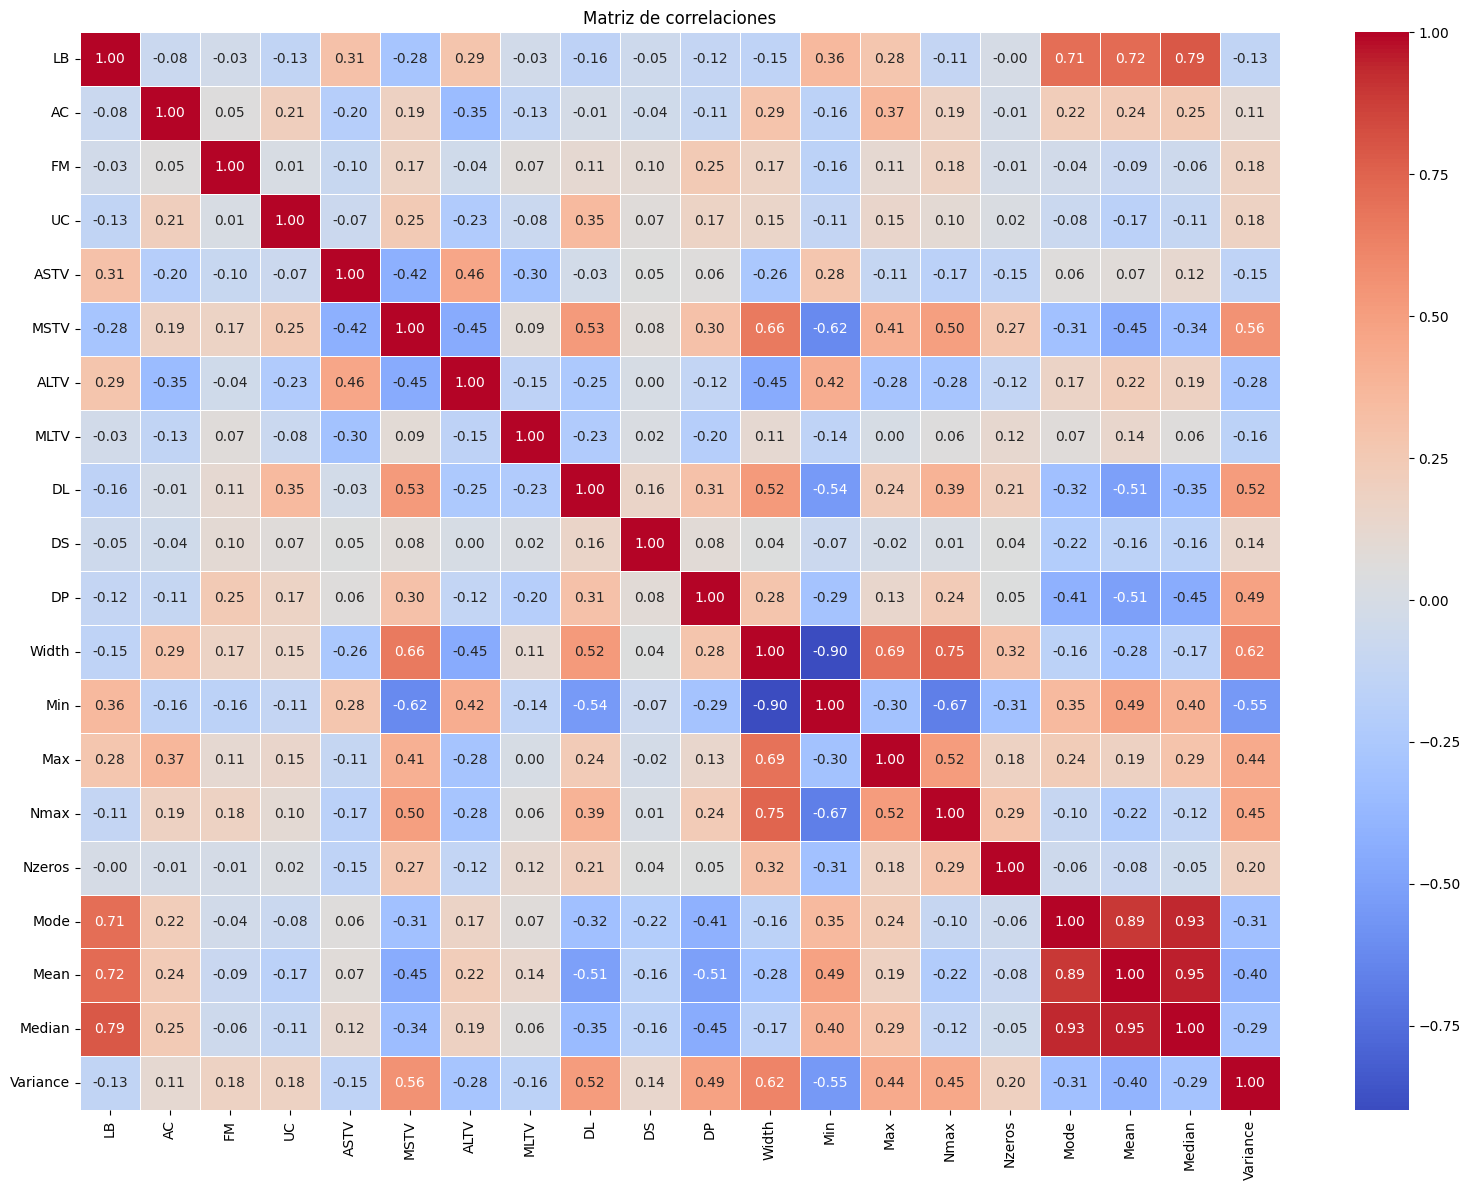

In [ ]:
#Matriz de correlación
print("Matriz de correlaciones \n")

#Seleccionar solo columnas numéricas para evitar errores
numeric_df = df.select_dtypes(include=[np.number])

# Eliminamos variables (igual que la plantilla original, con Tendency y CLASS añadidas por ser categóricas)
columns_to_drop = ['DR','FileName', 'Date', 'SegFile', 'LBE', 'NSP', 'b', 'e', 'Tendency', 'CLASS',
                    'A','B','C','D','E','AD','DE','LD','FS','SUSP']
numeric_df = numeric_df.drop(columns=columns_to_drop, errors='ignore')

# Matriz de correlaciones
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

## **2. Tratamiento de Missing**

In [ ]:
#Tratamiento de valores faltantes
print("Tratamiento de valores faltantes \n")
missing_values = df.isnull().sum()
print("Valores faltantes por variable:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No hay valores faltantes")

Tratamiento de valores faltantes 

Valores faltantes por variable:
FileName    3
Date        3
SegFile     3
b           3
e           3
LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           3
B           3
C           3
D           3
E           3
AD          3
DE          3
LD          3
FS          3
SUSP        3
CLASS       3
NSP         3
dtype: int64


### ⚠️ Corrección: estas 3 filas no son pacientes reales

Antes de imputar nada, hay que investigar **por qué** faltan esos valores — no asumir que se rellenan automáticamente con la media. Al revisar las filas con valores faltantes, ninguna tiene `FileName` ni `NSP` — es decir, no corresponden a ningún examen CTG real, sino a filas residuales (resumen min/max) que quedaron pegadas al final del archivo original de Excel.

**Decisión y justificación:** se eliminan estas 3 filas (no se imputan), porque imputar la media sobre una fila que no es una observación real generaría un registro artificial — por ejemplo, `NSP` quedaría con un valor de 1.30, que no es una categoría clínica válida (NSP solo existe como 1, 2 o 3). Tras la eliminación, el dataset queda en 2126 registros, que coincide exactamente con la documentación oficial del dataset (UCI Machine Learning Repository).

In [ ]:
# Verificar que las filas con missing no son pacientes reales
print(df[df['NSP'].isna()][['FileName','NSP']])
print()

# Eliminar (no imputar) las filas que no son observaciones reales
df = df[df['NSP'].notna()].copy()
print(f"Filas tras eliminar las no-observaciones: {len(df)}")
print(f"¿Coincide con las 2126 documentadas oficialmente? {len(df) == 2126}")

     FileName  NSP
2126      NaN  NaN
2127      NaN  NaN
2128      NaN  NaN

Filas tras eliminar las no-observaciones: 2126
¿Coincide con las 2126 documentadas oficialmente? True


In [ ]:
# Revisar valores despues de la limpieza
print("\nValores faltantes tras la limpieza \n")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "No hay valores faltantes reales")


Valores faltantes tras la limpieza 

No hay valores faltantes reales


### Demostración de la técnica de imputación (referencia)

El dataset real, una vez limpio de las filas que no son observaciones, **no tiene valores faltantes genuinos** que requieran imputación. Aun así, se demuestra la técnica de imputación por media (igual que en la plantilla original), simulando valores faltantes artificiales solo con fines de referencia — esto no se aplica al análisis final, solo evidencia el manejo de la técnica.

In [ ]:
df_original = df.copy()
df_mask = df_original.copy()[numeric_cols_reales]
np.random.seed(42)
mask = np.random.rand(*df_mask.shape) < 0.1  # 10% de NaN simulado
df_mask[mask] = np.nan

# Imputación
imputer_mean = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer_mean.fit_transform(df_mask), columns=df_mask.columns)

print("Valores simulados como faltantes:", df_mask.isna().sum().sum())
print("Valores tras imputar con la media:", df_imputed.isna().sum().sum())

Valores simulados como faltantes: 4286
Valores tras imputar con la media: 0


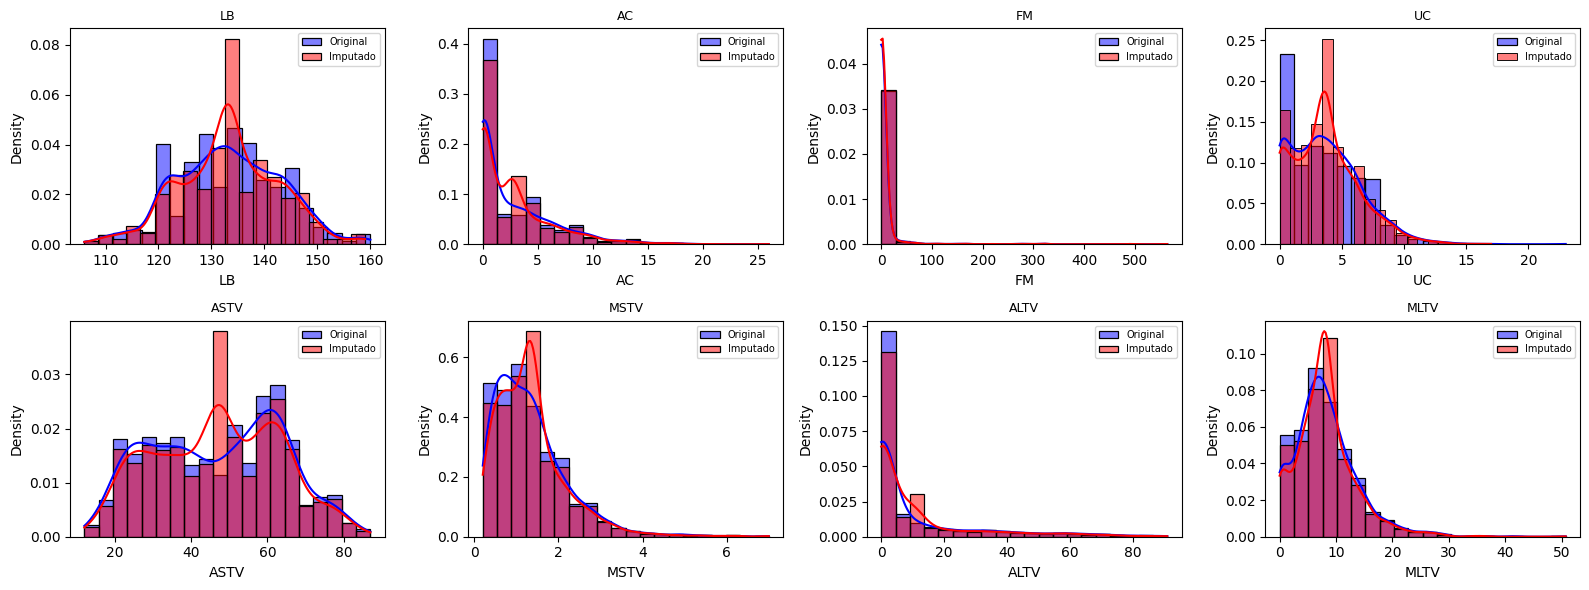

In [ ]:
# Función para comparar distribuciones (igual que la plantilla original)
def plot_macro_imputation_comparison(df_original, df_imputed, cols, ncols=4):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
    axs = axs.flatten()
    for i, col in enumerate(cols):
        ax = axs[i]
        sns.histplot(df_original[col].dropna(), bins=20, color='blue', stat='density', kde=True, label='Original', alpha=0.5, ax=ax)
        sns.histplot(df_imputed[col].dropna(), bins=20, color='red', stat='density', kde=True, label='Imputado', ax=ax)
        ax.set_title(col, fontsize=9)
        ax.legend(fontsize=7)
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])
    plt.tight_layout()
    plt.show()

plot_macro_imputation_comparison(df_original, df_imputed, numeric_cols_reales[:8])

# **3. Detección de Anomalías**

### ⚠️ Corrección: no se incluye NSP/CLASS como variable de entrada

La plantilla original selecciona todas las columnas numéricas (`select_dtypes(include=[np.number])`), lo que incluye sin querer a `NSP` (la propia variable clínica objetivo) y `CLASS` como si fueran mediciones fisiológicas más. Detectar anomalías usando la etiqueta que se supone no conoces de antemano distorsiona el resultado. Aquí se usa `numeric_cols_reales`, que excluye correctamente NSP, CLASS y las demás variables categóricas.

Cantidad de anomalías detectadas: 107


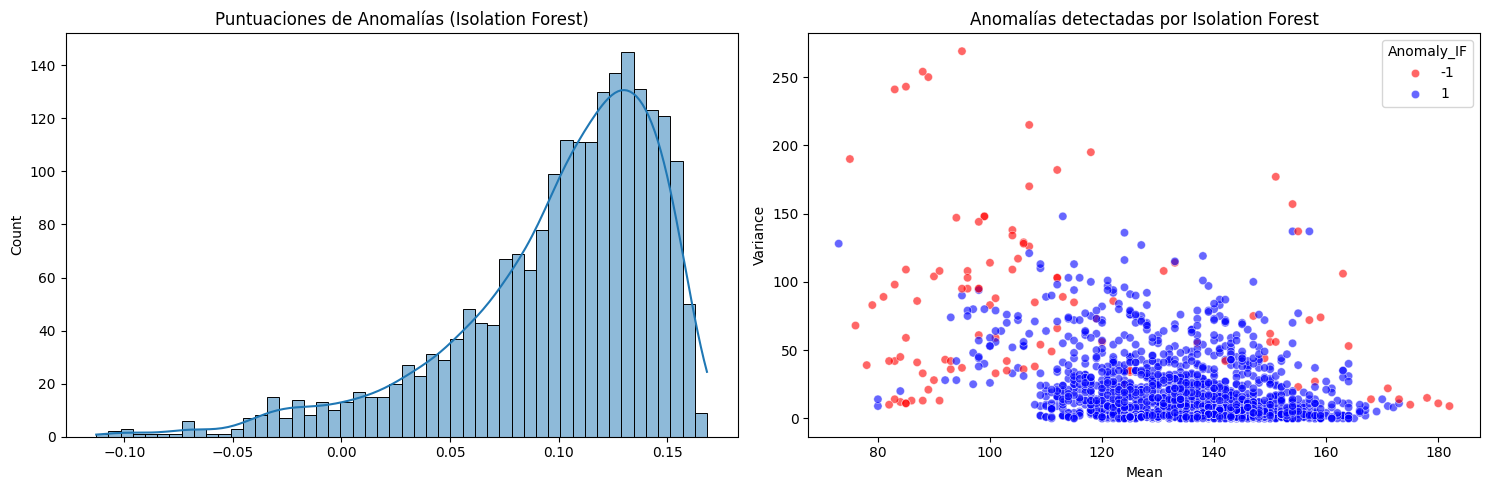

In [ ]:
df_num = df[numeric_cols_reales]  # solo variables numéricas reales, sin NSP/CLASS

# Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

# Aplicar Isolation Forest para detección de anomalías
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # 5% de anomalías estimadas
df["Anomaly_IF"] = iso_forest.fit_predict(df_scaled)  # -1 indica anomalía, 1 indica normal

print("Cantidad de anomalías detectadas:", (df["Anomaly_IF"] == -1).sum())

# Distribución de puntuaciones de anomalía
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(iso_forest.decision_function(df_scaled), bins=50, kde=True)
plt.title("Puntuaciones de Anomalías (Isolation Forest)")

# Gráfico de dispersión sobre dos variables clínicas reales (Mean vs Variance)
plt.subplot(1,2,2)
sns.scatterplot(x=df_num['Mean'], y=df_num['Variance'], hue=df["Anomaly_IF"], palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title("Anomalías detectadas por Isolation Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Validación: ¿las anomalías (sin conocer NSP) coinciden con los casos clínicos reales?
df['NSP_label'] = df['NSP'].map(nsp_labels)
cross = pd.crosstab(df['Anomaly_IF'].map({1:'Normal', -1:'Anómalo'}), df['NSP_label'], normalize='index').round(3)*100
print(cross)

NSP_label   Normal  Patológico  Sospechoso
Anomaly_IF                                
Anómalo       38.3        53.3         8.4
Normal        79.9         5.9        14.2


# 4. Agrupamiento K-means

Métrica de silhouette para K-Means: 0.172


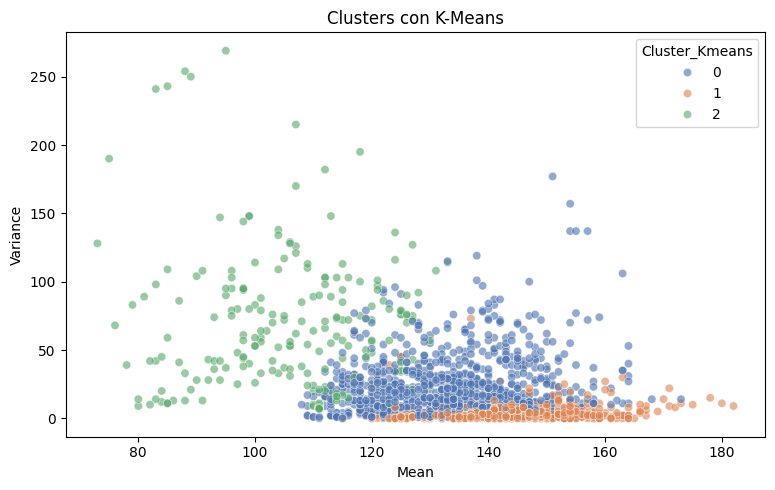

In [ ]:
# Ya usamos df_scaled con las variables numéricas reales (sin NSP/CLASS)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster_Kmeans"] = kmeans.fit_predict(df_scaled)

silhouette_kmeans = silhouette_score(df_scaled, df["Cluster_Kmeans"])
print(f"Métrica de silhouette para K-Means: {silhouette_kmeans:.3f}")

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.scatterplot(x=df_num['Mean'], y=df_num['Variance'], hue=df["Cluster_Kmeans"], palette="deep", alpha=0.6)
plt.title("Clusters con K-Means")
plt.tight_layout()
plt.show()

In [ ]:
# Comparación de clusters contra la clase clínica real
cross_cluster = pd.crosstab(df['Cluster_Kmeans'], df['NSP_label'], normalize='index').round(3)*100
print(cross_cluster)

NSP_label       Normal  Patológico  Sospechoso
Cluster_Kmeans                                
0                 96.4         0.1         3.5
1                 63.1         8.1        28.8
2                 45.4        49.1         5.6


### DBSCAN (técnica adicional, no exigida por la plantilla pero suma a la rúbrica de "técnicas de agrupamiento")

In [ ]:
dbs = DBSCAN(eps=2.2, min_samples=10)
labels_db = dbs.fit_predict(df_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f"Clusters DBSCAN: {n_clusters_db}, puntos de ruido: {n_noise} ({n_noise/len(df)*100:.1f}%)")

if n_clusters_db > 1:
    mask_valid = labels_db != -1
    sil_db = silhouette_score(df_scaled[mask_valid], labels_db[mask_valid])
    print(f"Silhouette DBSCAN (sin ruido): {sil_db:.3f}")

Clusters DBSCAN: 5, puntos de ruido: 509 (23.9%)
Silhouette DBSCAN (sin ruido): 0.064
